In [1]:
import numpy as np
import torch

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

# Test inversibility

In [4]:
import pickle

In [5]:
ntrain=100_000
rootdir="./results/results_glow_model_"+str(ntrain)

with open(rootdir+'z_init_T1.0.pkl', 'rb') as f:
    z_init = pickle.load(f)
with open(rootdir+'z_out_norm_A_T1.0.pkl', 'rb') as f:
    z_out_A = pickle.load(f)
with open(rootdir+'z_out_norm_B_T1.0.pkl', 'rb') as f:
    z_out_B = pickle.load(f)


In [6]:
n_blocks = len(z_out_A.keys())

2

In [8]:
tst_in = z_init[0].flatten()
tst_out_A = z_out_A[0].flatten()
tst_out_B = z_out_B[0].flatten()
for ib in range(1,n_blocks):
    tst_in =  np.hstack((tst_in, z_init[ib].flatten()))
    tst_out_A = np.hstack((tst_out_A, z_out_A[ib].flatten()))
    tst_out_B = np.hstack((tst_out_B, z_out_B[ib].flatten()))

In [9]:
from scipy.stats import norm

In [10]:
loc=0.0
scale=1.0
x_norm = np.linspace(norm.ppf(0.000001,loc=loc,scale=scale), norm.ppf(0.999999,loc=loc,scale=scale), 100)

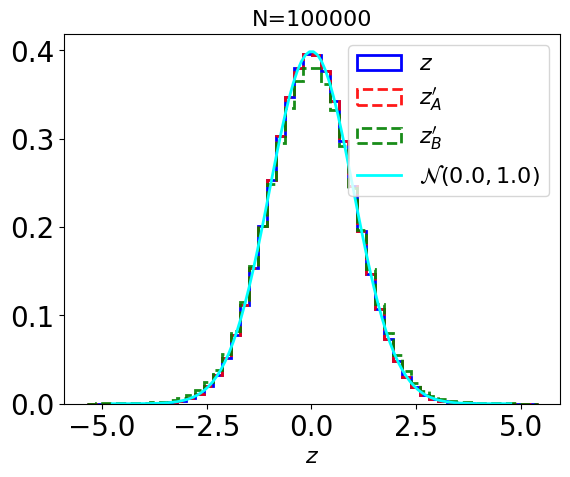

In [11]:
n_z,bins,_ =plt.hist(tst_in,bins=50,density=True,label=r"$z$",histtype="step",color='blue',lw=2);
n_zA,*_ =plt.hist(tst_out_A,bins=bins,density=True,label=r"$z^\prime_A$",alpha=0.9,color='red',histtype="step",lw=2,ls="--");
n_zB,*_ =plt.hist(tst_out_B,bins=bins,density=True,label=r"$z^\prime_B$",alpha=0.9,color="green",histtype="step",lw=2,ls="--");
plt.plot(x_norm,norm.pdf(x_norm,loc=loc,scale=scale),lw=2,c='cyan',label=f"$\mathcal{{N}}({loc},{scale})$")

plt.xlabel(r"$z$",fontsize=16)
plt.legend(fontsize=16);
plt.title(f"N={ntrain}",fontsize=16)
plt.savefig("fig-glow_"+str(ntrain)+"_test_inversibility_AB_1.pdf", format= 'pdf',
            bbox_inches="tight",dpi=600)


In [12]:
from scipy.stats import wasserstein_distance 

In [13]:
def no_nan(x):
    return x[~np.isnan(x)]

block 0:1-w($z,z^\prime_A$)=2.87e-06 1-w($z,z^\prime_B$)=6.14e-02 
block 1:1-w($z,z^\prime_A$)=2.50e-06 1-w($z,z^\prime_B$)=2.82e-02 


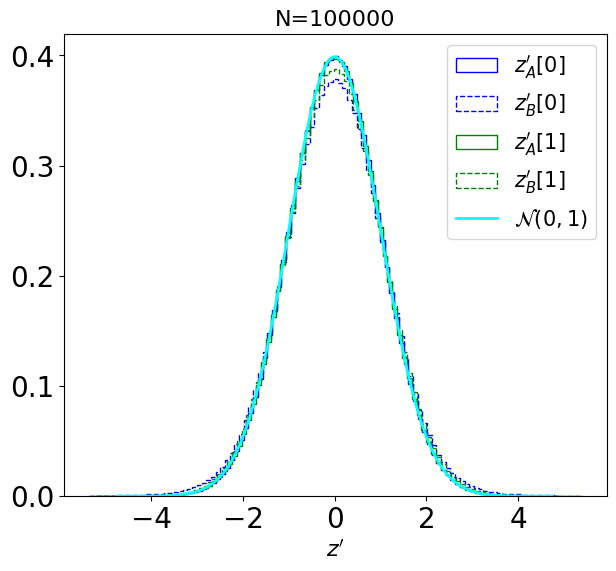

In [14]:
colors = ["blue","green","red"]
fig = plt.figure(figsize=(7,6))
for i in range(n_blocks):
    zA = no_nan(z_out_A[i].flatten())
    zB = no_nan(z_out_B[i].flatten())
    z  = no_nan(z_init[i].flatten())

    nz_A,bins,_ = plt.hist(zA,bins=100,density=True,label=f"$z^\prime_A$[{i}]",
                           histtype="step", color=colors[i]);
    nz_B, *_ =plt.hist(zB,bins=bins,density=True,label=f"$z^\prime_B$[{i}]",
                       histtype="step", color=colors[i],ls='--');
    n_z, *_= plt.hist(z,bins=bins,density=True,alpha=0.0);
    #n_z = np.histogram(z_init[i].flatten(),bins=bins,density=True)
    #print(f"block {i}: z size: {len(z_out_A[i].flatten())}, {len(z_out_B[i].flatten())}, {len(z_init[i].flatten())}")
    print(f"block {i}:"
          f"1-w($z,z^\prime_A$)={wasserstein_distance(bins[:-1],bins[:-1],nz_A,n_z):.2e} " 
        f"1-w($z,z^\prime_B$)={wasserstein_distance(bins[:-1],bins[:-1],nz_B,n_z):.2e} "
        )

plt.plot(x_norm,norm.pdf(x_norm,loc=loc,scale=scale),lw=2,c='cyan',label=f"$\mathcal{{N}}({loc:.0f},{scale:.0f})$")

#plt.xlim([-7,7])
plt.xlabel("$z^\prime$", fontsize=16)
plt.legend(fontsize=15);
plt.title(f"N={ntrain}",fontsize=16)
plt.savefig("fig-glow_"+str(ntrain)+"_test_inversibility_AB_blocks.pdf",
            format= 'pdf', bbox_inches="tight",dpi=600)

In [ ]:
n_vals = 10_000
fig=plt.figure(figsize=(5,5))
for i in range(n_blocks):
    if i==0:
        labels=['Model A','Model B']
    else:
        labels=[None,None]
    plt.scatter(z_init[i].flatten()[:n_vals],z_out_B[i].flatten()[:n_vals],s=1,label=labels[1],color='orange')
    plt.scatter(z_init[i].flatten()[:n_vals],z_out_A[i].flatten()[:n_vals],s=1,label=labels[0],color='blue')

plt.grid();
plt.xlabel(r"$z$",fontsize=16)
plt.ylabel(r"$z^\prime$",fontsize=16)
plt.xlim([-5,5])
plt.ylim([-5,5])
lgnd = plt.legend(loc="lower left", scatterpoints=1, fontsize=10)
print()
for handle in lgnd.legend_handles:
    handle.set_sizes([30.0])
plt.title(f"N={ntrain}",fontsize=16)
plt.savefig("fig-glow_"+str(ntrain)+"_test_inversibility_AB_2.pdf",
            format= 'pdf', bbox_inches="tight",dpi=600)


In [ ]:
fig,axs = plt.subplots(1,3,sharey=True,figsize=(12,4))
fig.subplots_adjust(wspace=0.1)
n_vals = 10_000
for i in range(n_blocks):
    axs[i].scatter(z_init[i].flatten()[:n_vals],z_out_B[i].flatten()[:n_vals],s=1,label="Model B",color='orange')
    axs[i].scatter(z_init[i].flatten()[:n_vals],z_out_A[i].flatten()[:n_vals],s=1,label="Model A",color='blue')
    axs[i].set_xlim([-5,5])
    axs[i].set_ylim([-5,5])
    axs[i].grid()
    axs[i].set_title(f"Block[{i}]")
    axs[i].set_xlabel(r"$z$",fontsize=16)

axs[0].set_ylabel(r"$z^\prime$",fontsize=16)
lgnd =axs[-1].legend(loc="lower left", scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([30.0])
#plt.tight_layout()
plt.savefig("fig-glow_"+str(ntrain)+"_test_inversibility_AB_3.pdf",
            format= 'pdf', bbox_inches="tight",dpi=600)
